In [23]:
from utils.cnn_utils.cnn_preprocessing_utils import CNNPreprocessor
cnn_preprocessor = CNNPreprocessor(sensors_path="../../../../data/ml/bending_features.csv", target_path="../../../../data/ml/targets.csv")
sensors_df, target_df = cnn_preprocessor.read_data()
sensors_df = cnn_preprocessor.feature_selection()
cnn_preprocessor.normalize_angle()
X = cnn_preprocessor.group_and_pad(cnn_preprocessor.sensor_df, group_col="Experiment_ID")
Y = cnn_preprocessor.group_and_pad(cnn_preprocessor.target_df, group_col="Experiment_ID")[:,:-1,1:-1]

In [45]:
inputs_train, data, inputs, targets_train = X[:,:,3:-1], X[0:10,:,3:-1], X[10:20,:,3:-1], Y[:,:,2:3]
inputs_train.shape, targets_train.shape

((100, 324, 12), (100, 46, 1))

In [50]:
import torch as th
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from tint.attr import LofKernelShap

# ---------------------------
# 1. Define RNN model
# ---------------------------
class SeqRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_timesteps):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)  # 1 output per timestep
        self.output_timesteps = output_timesteps

    def forward(self, x):
        # x: (batch, seq_len, features)
        out, _ = self.rnn(x)  # out: (batch, seq_len, hidden)
        
        # Use last timestep hidden state and expand for output sequence
        last_hidden = out[:, -1, :]  # (batch, hidden)
        repeated = last_hidden.unsqueeze(1).repeat(1, self.output_timesteps, 1)
        out_seq = self.fc(repeated)  # (batch, output_timesteps, 1)
        return out_seq

# ---------------------------
# 2. Prepare dummy data
# ---------------------------
# Training data: 100 samples
inputs_train = th.rand(100, 324, 12)
targets_train = th.rand(100, 46, 1)

# Inputs to explain: 10 samples
inputs = th.rand(10, 324, 12)
# Background dataset for SHAP: 32 samples
data = th.rand(32, 324, 12)

# ---------------------------
# 3. Initialize model, loss, optimizer
# ---------------------------
model = SeqRNN(input_size=12, hidden_size=64, output_timesteps=46)
criterion = nn.MSELoss()
optimizer = th.optim.Adam(model.parameters(), lr=0.001)

# ---------------------------
# 4. Train the model
# ---------------------------
epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(inputs_train)
    loss = criterion(outputs, targets_train)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")



Epoch 50/5000, Loss: 0.0836
Epoch 100/5000, Loss: 0.0819
Epoch 150/5000, Loss: 0.0811
Epoch 200/5000, Loss: 0.0808
Epoch 250/5000, Loss: 0.0805
Epoch 300/5000, Loss: 0.0804
Epoch 350/5000, Loss: 0.0803
Epoch 400/5000, Loss: 0.0802
Epoch 450/5000, Loss: 0.0801
Epoch 500/5000, Loss: 0.0800
Epoch 550/5000, Loss: 0.0799
Epoch 600/5000, Loss: 0.0798
Epoch 650/5000, Loss: 0.0797
Epoch 700/5000, Loss: 0.0796
Epoch 750/5000, Loss: 0.0795
Epoch 800/5000, Loss: 0.0795
Epoch 850/5000, Loss: 0.0795
Epoch 900/5000, Loss: 0.0794
Epoch 950/5000, Loss: 0.0794
Epoch 1000/5000, Loss: 0.0794
Epoch 1050/5000, Loss: 0.0794
Epoch 1100/5000, Loss: 0.0794
Epoch 1150/5000, Loss: 0.0793
Epoch 1200/5000, Loss: 0.0793
Epoch 1250/5000, Loss: 0.0793
Epoch 1300/5000, Loss: 0.0793
Epoch 1350/5000, Loss: 0.0793
Epoch 1400/5000, Loss: 0.0793
Epoch 1450/5000, Loss: 0.0793


KeyboardInterrupt: 

/home/arman/.conda/envs/winit/lib/python3.8/site-packages/captum/attr/_core/lime.py:1109: UserWarning: You are providing multiple inputs for Lime / Kernel SHAP attributions. This trains a separate interpretable model for each example, which can be time consuming. It is recommended to compute attributions for one example at a time.
  warnings.warn(


Attribution shape: torch.Size([10, 324, 12])


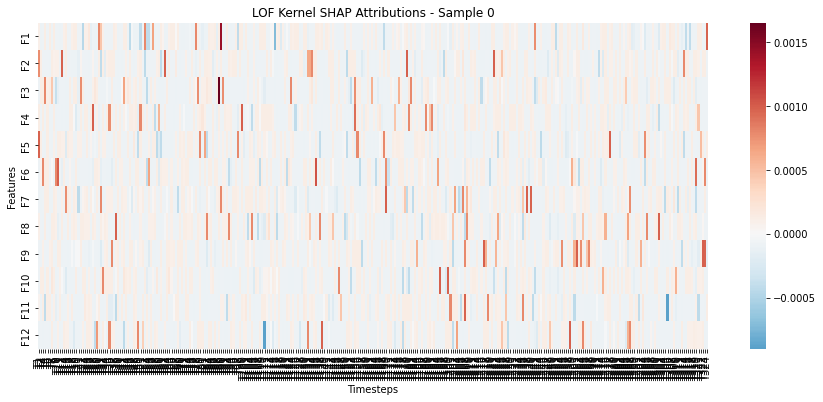

In [51]:
# ---------------------------
# 5. LOF Kernel SHAP explanation
# ---------------------------
explainer = LofKernelShap(model, data, n_neighbors=2)

# Explain first output timestep
attr = explainer.attribute(inputs, target=0)  # shape: (10, 324, 12)
print("Attribution shape:", attr.shape)

# ---------------------------
# 6. Heatmap visualization
# ---------------------------
sample_idx = 0
attr_sample = attr[sample_idx].detach().numpy()  # shape: (324, 12)

# Labels for timesteps and features
timesteps = [f"T{i+1}" for i in range(attr_sample.shape[0])]
features = [f"F{i+1}" for i in range(attr_sample.shape[1])]

plt.figure(figsize=(15, 6))
sns.heatmap(attr_sample.T, annot=False, cmap='RdBu_r', center=0,
            xticklabels=timesteps, yticklabels=features)

plt.xlabel("Timesteps")
plt.ylabel("Features")
plt.title(f"LOF Kernel SHAP Attributions - Sample {sample_idx}")
plt.show()


TemporalIntegratedGradients shape: torch.Size([2, 324, 12])


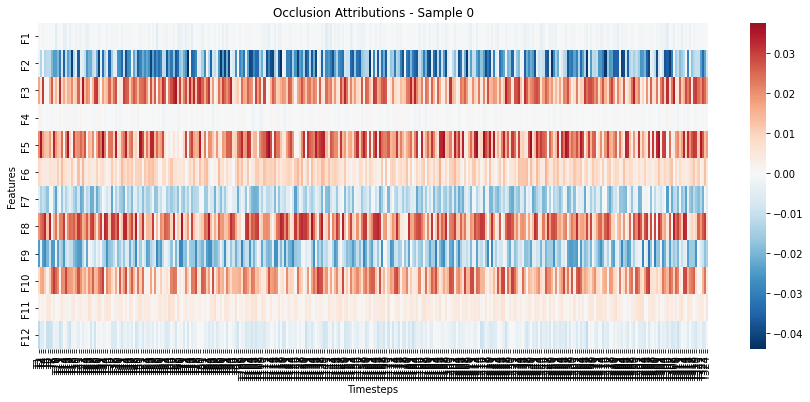

In [52]:
from tint.attr import Occlusion, TemporalIntegratedGradients
# ---------------------------
# 4b. Explain using TemporalIntegratedGradients
# ---------------------------
tig_explainer = TemporalIntegratedGradients(model)
attr_tig = tig_explainer.attribute(inputs[:2], target=0)
print("TemporalIntegratedGradients shape:", attr_tig.shape)

# ---------------------------
# 5. Visualize (example: first sample, first method)
# ---------------------------
sample_idx = 0
attr_sample = attr_tig[sample_idx].detach().numpy()  # (324, 12)

timesteps = [f"T{i+1}" for i in range(attr_sample.shape[0])]
features = [f"F{i+1}" for i in range(attr_sample.shape[1])]

plt.figure(figsize=(15, 6))
sns.heatmap(attr_sample.T, annot=False, cmap='RdBu_r', center=0,
            xticklabels=timesteps, yticklabels=features)
plt.xlabel("Timesteps")
plt.ylabel("Features")
plt.title("Occlusion Attributions - Sample 0")
plt.show()

TemporalIntegratedGradients shape: torch.Size([2, 324, 12])


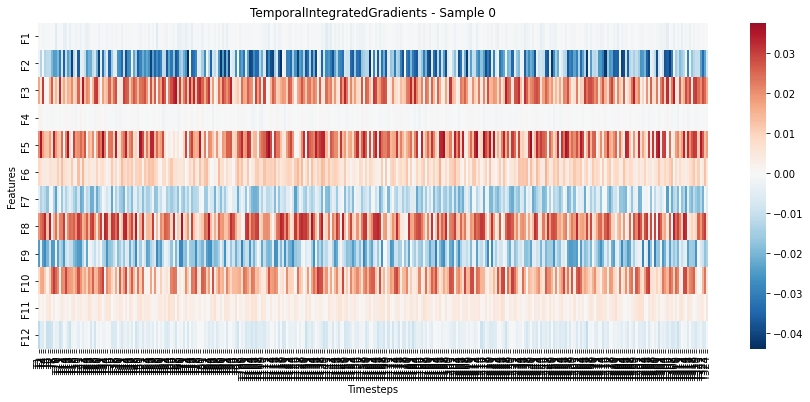

In [54]:
from tint.attr import TemporalIntegratedGradients, SequentialIntegratedGradients
# ---------------------------
# 4a. TemporalIntegratedGradients
# ---------------------------
tig_explainer = TemporalIntegratedGradients(model)
attr_tig = tig_explainer.attribute(inputs[:2], target=0)  # explain first output timestep
print("TemporalIntegratedGradients shape:", attr_tig.shape)

# ---------------------------
# 5. Heatmap visualization
# ---------------------------
sample_idx = 0
attr_sample = attr_tig[sample_idx].detach().numpy()  # example: TIG

timesteps = [f"T{i+1}" for i in range(attr_sample.shape[0])]
features = [f"F{i+1}" for i in range(attr_sample.shape[1])]

plt.figure(figsize=(15, 6))
sns.heatmap(attr_sample.T, annot=False, cmap='RdBu_r', center=0,
            xticklabels=timesteps, yticklabels=features)
plt.xlabel("Timesteps")
plt.ylabel("Features")
plt.title("TemporalIntegratedGradients - Sample 0")
plt.show()

SequentialIntegratedGradients shape: torch.Size([2, 324, 12])


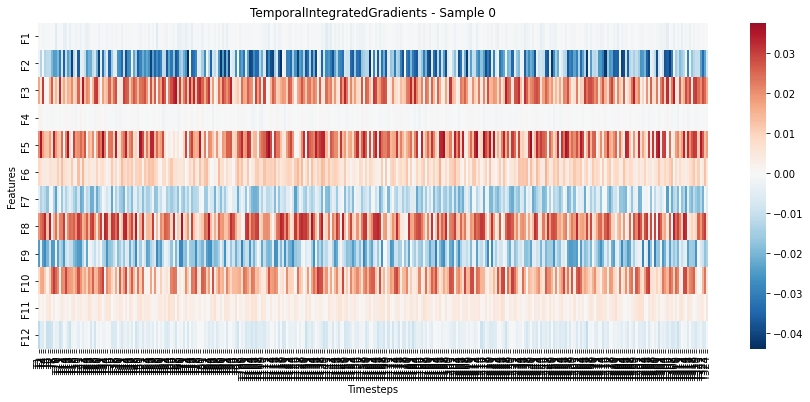

In [55]:
# ---------------------------
# 4b. SequentialIntegratedGradients
# ---------------------------
sig_explainer = SequentialIntegratedGradients(model)
attr_sig = sig_explainer.attribute(inputs[:2], target=0)
print("SequentialIntegratedGradients shape:", attr_sig.shape)

# ---------------------------
# 5. Heatmap visualization
# ---------------------------
sample_idx = 0
attr_sample = attr_tig[sample_idx].detach().numpy()  # example: TIG

timesteps = [f"T{i+1}" for i in range(attr_sample.shape[0])]
features = [f"F{i+1}" for i in range(attr_sample.shape[1])]

plt.figure(figsize=(15, 6))
sns.heatmap(attr_sample.T, annot=False, cmap='RdBu_r', center=0,
            xticklabels=timesteps, yticklabels=features)
plt.xlabel("Timesteps")
plt.ylabel("Features")
plt.title("TemporalIntegratedGradients - Sample 0")
plt.show()